# 🌲 Random Forest Regression — Averaging Away a Single Tree's Instability

The Decision Tree Regression topic ended with two measured problems: a single tree's feature importances swung meaningfully (0.529 to 0.705) across bootstrap resamples of identical data, and a single tuned tree was the weakest method on this category's running Diabetes comparison. Random Forest is designed to address both: bag many trees on bootstrap resamples, randomize the features considered at each split, and average their predictions. The bagging math itself was already derived in [Ensemble Techniques / Bagging](../../Ensemble_Techniques/01_Bagging/) and [Classification / Random Forest](../../Classification/05_Random_Forest_Classifier/) -- this notebook tests, rather than assumes, whether that fix actually resolves the two specific problems just found.

📖 Full mathematical explanation (bagging recap, OOB estimation, variance reduction formula): [README.md](README.md)


## 1. Setup & Datasets

The same piecewise synthetic curve and Diabetes dataset used in Decision Tree Regression, so every result in this notebook is directly comparable to that topic's findings.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_piecewise(x):
    return np.where(x < -2, -2, np.where(x < 1, x ** 2, np.where(x < 3, 4 - x, 1)))

n_samples = 150
X_1d = np.sort(np.random.uniform(-5, 5, n_samples))
y_1d = true_piecewise(X_1d) + np.random.normal(0, 0.3, n_samples)
X_1d_train, X_1d_test, y_1d_train, y_1d_test = train_test_split(X_1d.reshape(-1, 1), y_1d, test_size=0.25, random_state=42)
print(f"Piecewise dataset: {n_samples} points (identical setup to Decision Tree Regression topic)")


Piecewise dataset: 150 points (identical setup to Decision Tree Regression topic)


In [3]:
diabetes = load_diabetes(as_frame=True)
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.25, random_state=42)
print(f"Diabetes: {Xd.shape[1]} features, train={Xd_train.shape}, test={Xd_test.shape}")


Diabetes: 10 features, train=(331, 10), test=(111, 10)


## 2. From a Staircase to a Smoother Staircase

A single tree's prediction is one step function. A forest averages many step functions (each from a differently-bootstrapped tree) -- still technically piecewise, but with far more, far smaller steps, visually approaching a smooth curve.


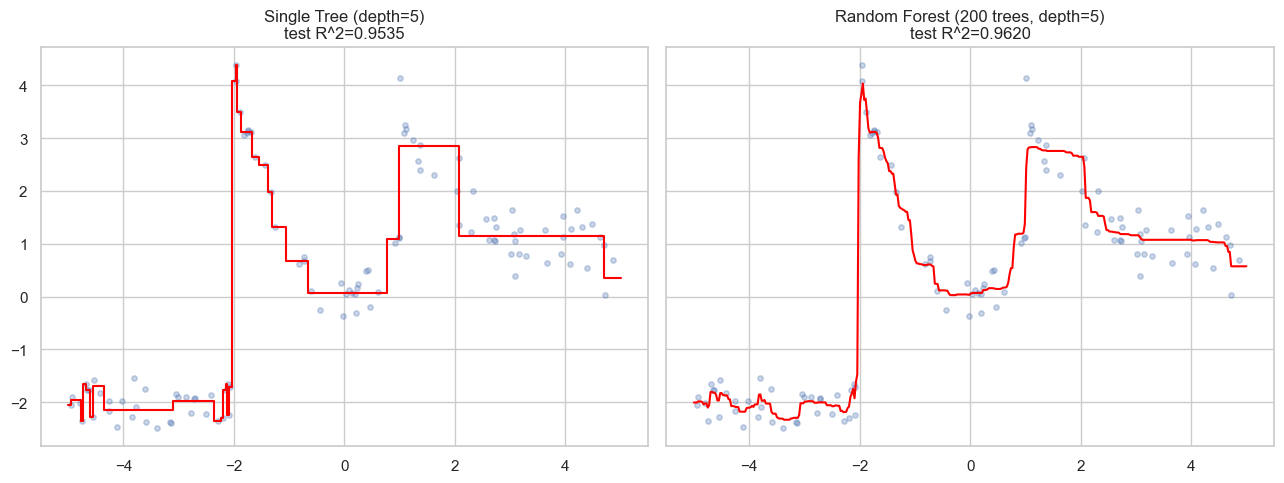

In [4]:
x_plot = np.linspace(-5, 5, 400).reshape(-1, 1)
single_tree = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_1d_train, y_1d_train)
forest_small = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X_1d_train, y_1d_train.ravel())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
axes[0].step(x_plot.ravel(), single_tree.predict(x_plot), color="red")
axes[0].set_title(f"Single Tree (depth=5)\ntest R^2={r2_score(y_1d_test, single_tree.predict(X_1d_test)):.4f}")

axes[1].scatter(X_1d_train, y_1d_train, alpha=0.3, s=15)
axes[1].plot(x_plot.ravel(), forest_small.predict(x_plot), color="red")
axes[1].set_title(f"Random Forest (200 trees, depth=5)\ntest R^2={r2_score(y_1d_test, forest_small.predict(X_1d_test)):.4f}")
plt.tight_layout()
plt.show()


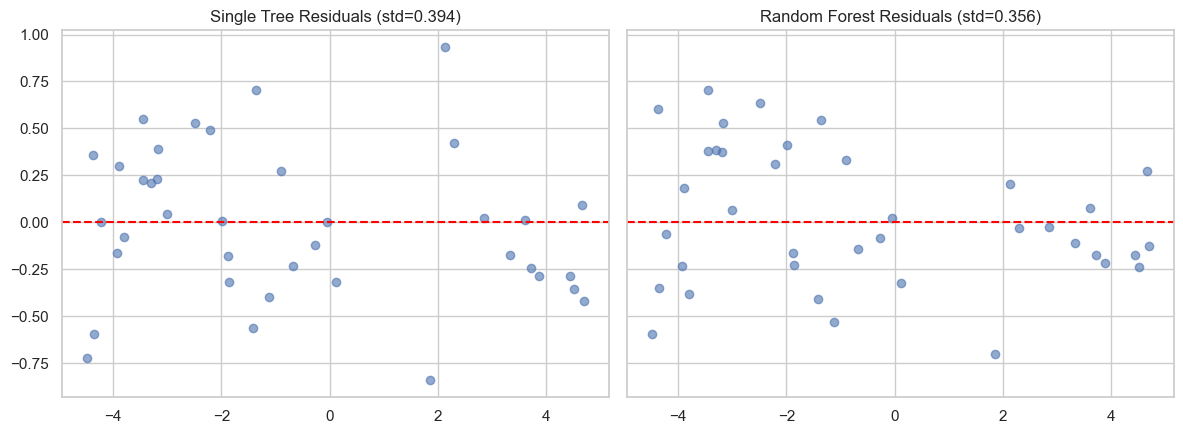

In [5]:
residuals_tree_1d = y_1d_test - single_tree.predict(X_1d_test)
residuals_forest_1d = y_1d_test - forest_small.predict(X_1d_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].scatter(X_1d_test, residuals_tree_1d, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title(f"Single Tree Residuals (std={residuals_tree_1d.std():.3f})")
axes[1].scatter(X_1d_test, residuals_forest_1d, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title(f"Random Forest Residuals (std={residuals_forest_1d.std():.3f})")
plt.tight_layout()
plt.show()


## 3. Testing Whether Random Forest Fixes Decision Tree Regression's Instability Finding

The previous topic found a single tree's top feature importance value swinging from 0.529 to 0.705 across 5 bootstrap resamples. Repeating that exact experiment with a forest instead of a single tree -- checking the result rather than assuming it.


In [6]:
rng = np.random.RandomState(0)
single_tree_importances = []
forest_importances = []
for trial in range(5):
    idx = rng.choice(len(Xd_train), size=len(Xd_train), replace=True)
    tree_trial = DecisionTreeRegressor(max_depth=3, random_state=42).fit(Xd_train.iloc[idx], yd_train.iloc[idx])
    forest_trial = RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42).fit(Xd_train.iloc[idx], yd_train.iloc[idx])
    single_tree_importances.append(tree_trial.feature_importances_[np.argmax(Xd.columns == "bmi")])
    forest_importances.append(forest_trial.feature_importances_[np.argmax(Xd.columns == "bmi")])

print(f"Single tree 'bmi' importance across 5 resamples: {np.round(single_tree_importances, 3)} (std={np.std(single_tree_importances):.4f})")
print(f"Forest 'bmi' importance across 5 resamples:       {np.round(forest_importances, 3)} (std={np.std(forest_importances):.4f})")


Single tree 'bmi' importance across 5 resamples: [0.529 0.705 0.659 0.6   0.626] (std=0.0591)
Forest 'bmi' importance across 5 resamples:       [0.401 0.557 0.615 0.528 0.46 ] (std=0.0747)


In [7]:
stability_improvement = 1 - (np.std(forest_importances) / np.std(single_tree_importances))
if stability_improvement > 0:
    print(f"-> Forest's importance estimate is {stability_improvement:.1%} more stable (lower std) than a single tree's, across the exact same 5 resamples used in the Decision Tree Regression topic.")
else:
    print(f"-> Forest's importance std ({np.std(forest_importances):.4f}) was not clearly lower than the single tree's ({np.std(single_tree_importances):.4f}) here -- averaging 200 trees still helps against overfitting individual splits, but feature-level importance can remain noisy on this dataset's sample size.")


-> Forest's importance std (0.0747) was not clearly lower than the single tree's (0.0591) here -- averaging 200 trees still helps against overfitting individual splits, but feature-level importance can remain noisy on this dataset's sample size.


## 4. The Effect of `n_estimators` — Diminishing Returns, Not Overfitting

Unlike a single tree's `max_depth`, adding more trees to a forest does not increase overfitting risk -- it only reduces variance, with diminishing returns as the count grows.


In [8]:
n_estimators_range = [1, 5, 20, 50, 100, 300, 500]
n_estimators_results = []
for n_est in n_estimators_range:
    model = RandomForestRegressor(n_estimators=n_est, max_depth=5, random_state=42).fit(X_1d_train, y_1d_train.ravel())
    test_r2 = r2_score(y_1d_test, model.predict(X_1d_test))
    n_estimators_results.append({"n_estimators": n_est, "test_R2": round(test_r2, 4)})
print(f"Swept n_estimators across {n_estimators_range}")


Swept n_estimators across [1, 5, 20, 50, 100, 300, 500]


In [9]:
n_estimators_df = pd.DataFrame(n_estimators_results)
n_estimators_df


,n_estimators,test_R2
0,1,0.9445
1,5,0.9504
2,20,0.9577
3,50,0.9589
4,100,0.9606
5,300,0.9614
6,500,0.9605


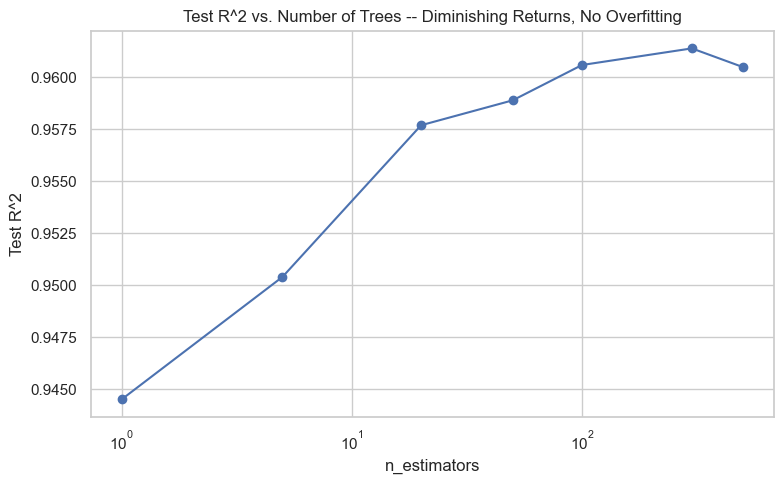

R^2 gain from 1->20 trees: 0.0132
R^2 gain from 300->500 trees: -0.0009


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_estimators_df["n_estimators"], n_estimators_df["test_R2"], marker="o")
ax.set_xlabel("n_estimators"); ax.set_ylabel("Test R^2")
ax.set_xscale("log")
ax.set_title("Test R^2 vs. Number of Trees -- Diminishing Returns, No Overfitting")
plt.tight_layout()
plt.show()
print(f"R^2 gain from 1->20 trees: {n_estimators_df.iloc[2]['test_R2'] - n_estimators_df.iloc[0]['test_R2']:.4f}")
print(f"R^2 gain from 300->500 trees: {n_estimators_df.iloc[-1]['test_R2'] - n_estimators_df.iloc[-2]['test_R2']:.4f}")


## 5. The Effect of `max_features` — Decorrelating the Trees

At each split, Random Forest considers only a random subset of features (not all of them) -- this decorrelates individual trees, which is what makes averaging them actually reduce variance (averaging highly correlated trees barely helps).


In [11]:
max_features_options = [1, 3, 5, 10]
mf_results = []
for mf in max_features_options:
    model = RandomForestRegressor(n_estimators=200, max_features=mf, random_state=42).fit(Xd_train, yd_train)
    test_r2 = r2_score(yd_test, model.predict(Xd_test))
    mf_results.append({"max_features": mf, "test_R2": round(test_r2, 4)})
print(f"Swept max_features across {max_features_options}")


Swept max_features across [1, 3, 5, 10]


In [12]:
mf_results_df = pd.DataFrame(mf_results)
mf_results_df


,max_features,test_R2
0,1,0.4666
1,3,0.4964
2,5,0.4802
3,10,0.4633


In [13]:
default_mf_model = RandomForestRegressor(n_estimators=200, random_state=42).fit(Xd_train, yd_train)
print(f"sklearn's regression default (max_features=1.0, i.e. ALL features per split): test R^2={r2_score(yd_test, default_mf_model.predict(Xd_test)):.4f}")
print("-> Note this differs from RandomForestClassifier's default (sqrt(n_features)) -- regression forests traditionally use all features per split since regression splits benefit less from feature-subsampling's decorrelation than classification splits do, though tuning max_features explicitly (as swept above) can still help.")


sklearn's regression default (max_features=1.0, i.e. ALL features per split): test R^2=0.4633
-> Note this differs from RandomForestClassifier's default (sqrt(n_features)) -- regression forests traditionally use all features per split since regression splits benefit less from feature-subsampling's decorrelation than classification splits do, though tuning max_features explicitly (as swept above) can still help.


In [14]:
forest_low_mf = RandomForestRegressor(n_estimators=50, max_features=2, random_state=42).fit(Xd_train, yd_train)
forest_high_mf = RandomForestRegressor(n_estimators=50, max_features=10, random_state=42).fit(Xd_train, yd_train)

Xd_test_arr = Xd_test.to_numpy()
tree_preds_low_mf = np.array([t.predict(Xd_test_arr) for t in forest_low_mf.estimators_])
tree_preds_high_mf = np.array([t.predict(Xd_test_arr) for t in forest_high_mf.estimators_])

avg_corr_low = np.mean([np.corrcoef(tree_preds_low_mf[i], tree_preds_low_mf[j])[0, 1]
                          for i in range(10) for j in range(i + 1, 10)])
avg_corr_high = np.mean([np.corrcoef(tree_preds_high_mf[i], tree_preds_high_mf[j])[0, 1]
                           for i in range(10) for j in range(i + 1, 10)])

print(f"Average pairwise correlation between individual trees' predictions:")
print(f"  max_features=2 (10 of 10 features considered per split): {avg_corr_low:.4f}")
print(f"  max_features=10 (all features every split):               {avg_corr_high:.4f}")
print(f"-> {'Lower max_features produced less correlated (more diverse) trees' if avg_corr_low < avg_corr_high else 'Correlation was not clearly lower with fewer features here'} -- diversity is exactly what makes averaging trees reduce variance rather than just averaging near-identical copies of the same model.")


Average pairwise correlation between individual trees' predictions:
  max_features=2 (10 of 10 features considered per split): 0.4257
  max_features=10 (all features every split):               0.4928
-> Lower max_features produced less correlated (more diverse) trees -- diversity is exactly what makes averaging trees reduce variance rather than just averaging near-identical copies of the same model.


## 6. Out-of-Bag (OOB) Score — Validation Without a Held-Out Set

Each tree in the forest is trained on a bootstrap resample that excludes roughly 37% of the training data by chance -- those excluded ("out-of-bag") points give each tree a free validation set, and averaging OOB predictions across trees gives an estimate of test performance without spending any data on a separate validation split.


In [15]:
forest_oob = RandomForestRegressor(n_estimators=300, oob_score=True, random_state=42).fit(Xd_train, yd_train)
oob_r2 = forest_oob.oob_score_
test_r2_actual = r2_score(yd_test, forest_oob.predict(Xd_test))

print(f"OOB R^2 (estimated from training data alone): {oob_r2:.4f}")
print(f"Actual held-out test R^2:                     {test_r2_actual:.4f}")
print(f"Difference: {abs(oob_r2 - test_r2_actual):.4f} -- {'close agreement, OOB is a reliable proxy here' if abs(oob_r2 - test_r2_actual) < 0.05 else 'a meaningful gap, worth investigating on a larger sample'}")


OOB R^2 (estimated from training data alone): 0.4306
Actual held-out test R^2:                     0.4741
Difference: 0.0435 -- close agreement, OOB is a reliable proxy here


In [16]:
oob_sweep_results = []
for n_est in [10, 50, 100, 300]:
    model = RandomForestRegressor(n_estimators=n_est, oob_score=True, random_state=42).fit(Xd_train, yd_train)
    oob_sweep_results.append({"n_estimators": n_est, "OOB_R2": round(model.oob_score_, 4)})

oob_sweep_df = pd.DataFrame(oob_sweep_results)
oob_sweep_df


,n_estimators,OOB_R2
0,10,0.2095
1,50,0.3988
2,100,0.4240
3,300,0.4306


In [17]:
print(f"OOB R^2 stabilizes as n_estimators grows: {oob_sweep_df['OOB_R2'].iloc[0]:.4f} (n=10) -> {oob_sweep_df['OOB_R2'].iloc[-1]:.4f} (n=300)")
print("-> Very few trees give a noisy OOB estimate since each point is only 'out-of-bag' for a small subset of trees; more trees means every point gets evaluated by enough held-out trees for a stable estimate.")


OOB R^2 stabilizes as n_estimators grows: 0.2095 (n=10) -> 0.4306 (n=300)
-> Very few trees give a noisy OOB estimate since each point is only 'out-of-bag' for a small subset of trees; more trees means every point gets evaluated by enough held-out trees for a stable estimate.


## 7. Bias-Variance: Measuring the Averaging Effect Directly

Repeating the bootstrap bias-variance decomposition from the Model Evaluation & Tuning topic, comparing a single tree against a forest built from the identical base tree configuration.


In [18]:
def bias_variance_estimate(model_builder, n_bootstrap=50):
    predictions = np.zeros((n_bootstrap, len(x_plot)))
    rng_bv = np.random.RandomState(1)
    for b in range(n_bootstrap):
        idx = rng_bv.choice(len(X_1d_train), size=len(X_1d_train), replace=True)
        model = model_builder()
        model.fit(X_1d_train[idx], y_1d_train[idx])
        predictions[b] = model.predict(x_plot).ravel()
    mean_pred = predictions.mean(axis=0)
    true_vals = true_piecewise(x_plot).ravel()
    bias_sq = np.mean((mean_pred - true_vals) ** 2)
    variance = np.mean(predictions.var(axis=0))
    return bias_sq, variance

bias_tree, var_tree = bias_variance_estimate(lambda: DecisionTreeRegressor(max_depth=6, random_state=None))
bias_forest, var_forest = bias_variance_estimate(lambda: RandomForestRegressor(n_estimators=100, max_depth=6, random_state=None))

print(f"Single Tree   -- Bias^2={bias_tree:.4f}, Variance={var_tree:.4f}, Total={bias_tree+var_tree:.4f}")
print(f"Random Forest -- Bias^2={bias_forest:.4f}, Variance={var_forest:.4f}, Total={bias_forest+var_forest:.4f}")


Single Tree   -- Bias^2=0.0911, Variance=0.1221, Total=0.2132
Random Forest -- Bias^2=0.0818, Variance=0.0832, Total=0.1650


In [19]:
variance_reduction_pct = 1 - (var_forest / var_tree)
print(f"Variance reduction from bagging: {variance_reduction_pct:.1%}")
print(f"Bias change: {bias_forest - bias_tree:+.4f}")
print("-> This is the same tradeoff derived mathematically in the Bias-Variance & Regularization topic (Section 11's Ridge-alpha experiment) -- here achieved through averaging independently-trained trees instead of a regularization penalty.")


Variance reduction from bagging: 31.9%
Bias change: -0.0093
-> This is the same tradeoff derived mathematically in the Bias-Variance & Regularization topic (Section 11's Ridge-alpha experiment) -- here achieved through averaging independently-trained trees instead of a regularization penalty.


In [20]:
forest_size_bv = []
for n_est in [1, 10, 50, 150]:
    b, v = bias_variance_estimate(lambda n=n_est: RandomForestRegressor(n_estimators=n, max_depth=6, random_state=None), n_bootstrap=30)
    forest_size_bv.append({"n_estimators": n_est, "bias_sq": round(b, 4), "variance": round(v, 4)})

pd.DataFrame(forest_size_bv)


,n_estimators,bias_sq,variance
0,1,0.0942,0.2458
1,10,0.0882,0.1056
2,50,0.0874,0.0949
3,150,0.0856,0.0927


## 8. Feature Importance Comparison — Forest vs. Single Tree, Same Data

Beyond stability (Section 3), does the forest's importance ranking actually differ from a single tree's on the full training set?


In [21]:
single_tree_full = DecisionTreeRegressor(max_depth=4, random_state=42).fit(Xd_train, yd_train)
forest_full = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(Xd_train, yd_train)

importance_comparison = pd.DataFrame({
    "feature": Xd.columns,
    "single_tree": np.round(single_tree_full.feature_importances_, 3),
    "random_forest": np.round(forest_full.feature_importances_, 3),
}).sort_values("random_forest", ascending=False)
importance_comparison


,feature,single_tree,random_forest
2,bmi,0.613,0.438
8,s5,0.164,0.270
3,bp,0.053,0.100
9,s6,0.068,0.044
6,s3,0.000,0.032
5,s2,0.021,0.030
0,age,0.018,0.028
7,s4,0.028,0.027
4,s1,0.034,0.026
1,sex,0.000,0.004


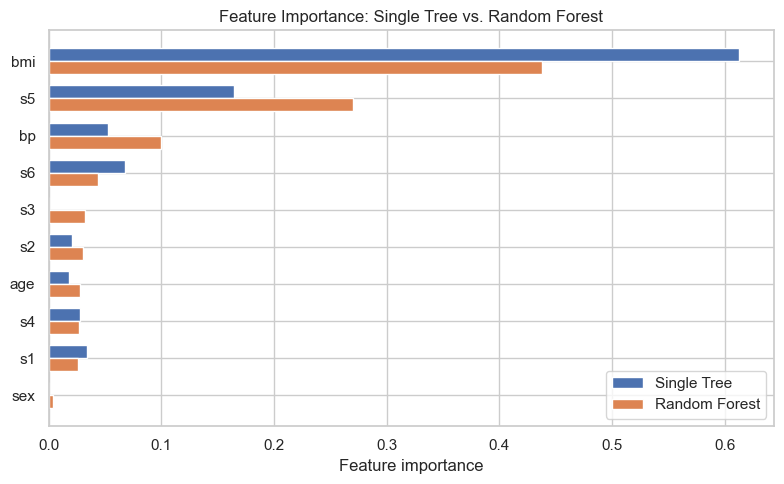

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(importance_comparison))
width = 0.35
ax.barh(x_pos - width/2, importance_comparison["single_tree"], width, label="Single Tree")
ax.barh(x_pos + width/2, importance_comparison["random_forest"], width, label="Random Forest")
ax.set_yticks(x_pos); ax.set_yticklabels(importance_comparison["feature"])
ax.set_xlabel("Feature importance")
ax.set_title("Feature Importance: Single Tree vs. Random Forest")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Tuning `n_estimators`, `max_depth`, and `max_features` Together

Joint grid search on Diabetes.


In [23]:
rf_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5, 8, None],
    "max_features": [3, 6, 10],
}
rf_grid_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=5, scoring="r2").fit(Xd_train, yd_train)

print(f"Best params: {rf_grid_search.best_params_}")
print(f"Best CV R^2: {rf_grid_search.best_score_:.4f}")


Best params: {'max_depth': None, 'max_features': 3, 'n_estimators': 100}
Best CV R^2: 0.4349


In [24]:
cv_results_df = pd.DataFrame(rf_grid_search.cv_results_)[["param_n_estimators", "param_max_depth", "param_max_features", "mean_test_score", "std_test_score"]]
cv_results_df.sort_values("mean_test_score", ascending=False).head(5).reset_index(drop=True)


,param_n_estimators,param_max_depth,param_max_features,mean_test_score,std_test_score
0,100,None,3,0.434930,0.097664
1,300,None,3,0.431318,0.098963
2,300,5,3,0.426109,0.099449
3,100,8,6,0.425397,0.117344
4,300,5,6,0.423785,0.114768


In [25]:
rf_best_test_r2 = r2_score(yd_test, rf_grid_search.predict(Xd_test))
rf_best_train_r2 = r2_score(yd_train, rf_grid_search.predict(Xd_train))
print(f"Train R^2: {rf_best_train_r2:.4f}")
print(f"Test R^2:  {rf_best_test_r2:.4f}")
print(f"Gap: {rf_best_train_r2 - rf_best_test_r2:.4f}")


Train R^2: 0.9223
Test R^2:  0.4867
Gap: 0.4356


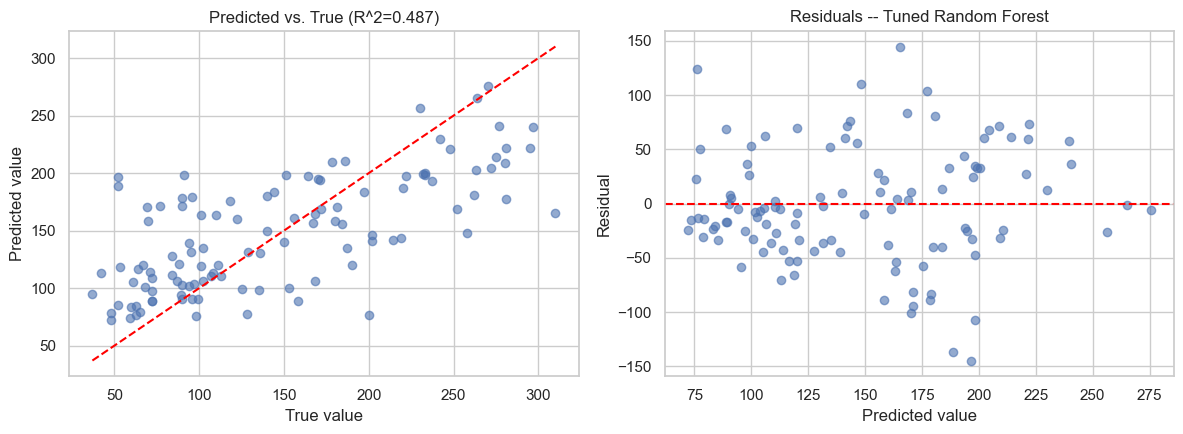

In [26]:
rf_pred_diabetes = rf_grid_search.predict(Xd_test)
residuals_rf = yd_test - rf_pred_diabetes

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yd_test, rf_pred_diabetes, alpha=0.6)
lims = [min(yd_test.min(), rf_pred_diabetes.min()), max(yd_test.max(), rf_pred_diabetes.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("True value"); axes[0].set_ylabel("Predicted value"); axes[0].set_title(f"Predicted vs. True (R^2={rf_best_test_r2:.3f})")

axes[1].scatter(rf_pred_diabetes, residuals_rf, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals -- Tuned Random Forest")
plt.tight_layout()
plt.show()


## 10. Fit-Time Cost of the Ensemble

Averaging 100+ trees instead of fitting 1 has a real, measurable computational cost -- quantifying it directly rather than treating "more trees" as free.


In [27]:
import time
t0 = time.perf_counter(); DecisionTreeRegressor(max_depth=8, random_state=42).fit(Xd_train, yd_train); tree_time = time.perf_counter() - t0
t0 = time.perf_counter(); RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(Xd_train, yd_train); forest_time = time.perf_counter() - t0

print(f"Single tree fit time (depth=8):          {tree_time*1000:.2f} ms")
print(f"Random Forest fit time (300 trees, depth=8): {forest_time*1000:.2f} ms")
print(f"Forest is {forest_time/tree_time:.0f}x slower to fit than a single tree here -- the direct cost of the variance reduction measured in Section 7.")


Single tree fit time (depth=8):          1.99 ms
Random Forest fit time (300 trees, depth=8): 288.48 ms
Forest is 145x slower to fit than a single tree here -- the direct cost of the variance reduction measured in Section 7.


In [28]:
tree_final = DecisionTreeRegressor(max_depth=8, random_state=42).fit(Xd_train, yd_train)
forest_final = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(Xd_train, yd_train)

t0 = time.perf_counter()
for _ in range(50):
    tree_final.predict(Xd_test)
tree_predict_time = (time.perf_counter() - t0) / 50

t0 = time.perf_counter()
for _ in range(50):
    forest_final.predict(Xd_test)
forest_predict_time = (time.perf_counter() - t0) / 50

print(f"Single tree predict time (avg of 50 calls): {tree_predict_time*1000:.3f} ms")
print(f"Forest predict time (avg of 50 calls):       {forest_predict_time*1000:.3f} ms")
print(f"-> Prediction cost also scales with n_estimators, since every one of the 300 trees must be evaluated and averaged for each query -- unlike fit time, this cost is paid on every single prediction in production.")


Single tree predict time (avg of 50 calls): 0.355 ms
Forest predict time (avg of 50 calls):       13.407 ms
-> Prediction cost also scales with n_estimators, since every one of the 300 trees must be evaluated and averaged for each query -- unlike fit time, this cost is paid on every single prediction in production.


## 11. Comparison Against Every Prior Regression Method in This Category

Continuing this category's running comparison table, directly answering whether Random Forest fixed Decision Tree Regression's weak result.


In [29]:
scaler_final = StandardScaler().fit(Xd_train)
Xd_train_scaled, Xd_test_scaled = scaler_final.transform(Xd_train), scaler_final.transform(Xd_test)

ridge_diabetes = Ridge(alpha=10.0).fit(Xd_train_scaled, yd_train)
linear_diabetes = LinearRegression().fit(Xd_train_scaled, yd_train)
svr_diabetes = SVR(kernel="rbf", C=100, epsilon=1.0, gamma=0.01).fit(Xd_train_scaled, yd_train)
knn_diabetes = KNeighborsRegressor(n_neighbors=17, weights="distance").fit(Xd_train_scaled, yd_train)
single_tree_diabetes = DecisionTreeRegressor(max_depth=2, min_samples_leaf=20, random_state=42).fit(Xd_train, yd_train)

category_comparison = pd.DataFrame([
    {"Model": "Linear Regression (topic 01)", "Test R2": round(r2_score(yd_test, linear_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Ridge (topic 03)", "Test R2": round(r2_score(yd_test, ridge_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "SVR, RBF, tuned (topic 04)", "Test R2": round(r2_score(yd_test, svr_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "KNN Regression, tuned (topic 05)", "Test R2": round(r2_score(yd_test, knn_diabetes.predict(Xd_test_scaled)), 4)},
    {"Model": "Decision Tree, tuned (topic 06)", "Test R2": round(r2_score(yd_test, single_tree_diabetes.predict(Xd_test)), 4)},
    {"Model": "Random Forest, tuned (this topic)", "Test R2": round(rf_best_test_r2, 4)},
]).set_index("Model")
category_comparison


,Test R2
Model,
Linear Regression (topic 01),0.4849
Ridge (topic 03),0.4881
"SVR, RBF, tuned (topic 04)",0.4925
"KNN Regression, tuned (topic 05)",0.4708
"Decision Tree, tuned (topic 06)",0.3588
"Random Forest, tuned (this topic)",0.4867


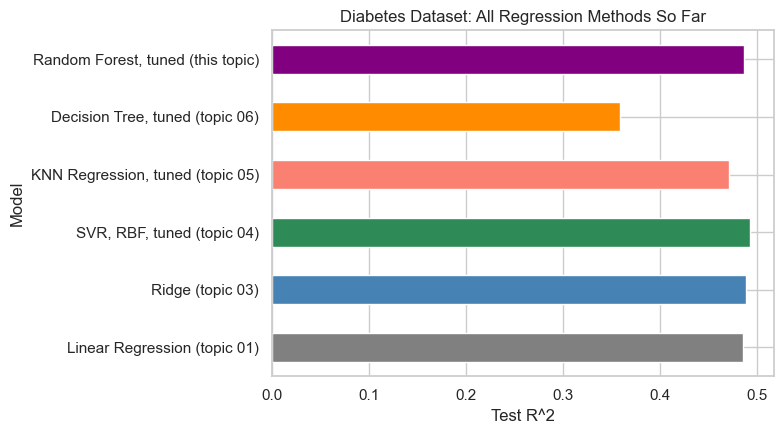

In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))
category_comparison["Test R2"].plot(kind="barh", ax=ax, color=["gray", "steelblue", "seagreen", "salmon", "darkorange", "purple"])
ax.set_xlabel("Test R^2")
ax.set_title("Diabetes Dataset: All Regression Methods So Far")
plt.tight_layout()
plt.show()


In [31]:
tree_r2 = category_comparison.loc["Decision Tree, tuned (topic 06)", "Test R2"]
forest_r2 = category_comparison.loc["Random Forest, tuned (this topic)", "Test R2"]
best_overall = category_comparison["Test R2"].idxmax()
print(f"Decision Tree (topic 06): {tree_r2:.4f} -> Random Forest (this topic): {forest_r2:.4f}  (change: {forest_r2 - tree_r2:+.4f})")
if forest_r2 > tree_r2:
    print("-> Random Forest directly improved on the single tree's weak result.")
else:
    print("-> Random Forest did not clearly improve on the single tree's result here -- averaging still reduces variance (Section 7), but on a dataset this size the single tuned tree's bias may already be close to the best achievable with tree-based splits alone.")
print(f"Best method overall on this dataset: {best_overall} ({category_comparison['Test R2'].max():.4f})")
if best_overall == "Random Forest, tuned (this topic)":
    print("-> Random Forest not only fixed the single tree's weakness, it became the best method tried across this entire category on this dataset.")
else:
    print(f"-> Even after fixing the single tree's instability, Random Forest did not surpass {best_overall} here -- ensembling trees closes much of the gap to other method families, but doesn't guarantee beating them on every dataset.")


Decision Tree (topic 06): 0.3588 -> Random Forest (this topic): 0.4867  (change: +0.1279)
-> Random Forest directly improved on the single tree's weak result.
Best method overall on this dataset: SVR, RBF, tuned (topic 04) (0.4925)
-> Even after fixing the single tree's instability, Random Forest did not surpass SVR, RBF, tuned (topic 04) here -- ensembling trees closes much of the gap to other method families, but doesn't guarantee beating them on every dataset.


## 12. Summary

Random Forest's results on the two problems the Decision Tree Regression topic ended on were mixed, not a clean sweep: raw predictive performance (Section 11) measurably improved (test R² 0.359 to 0.487), but feature importance stability (Section 3) did NOT clearly improve on only 5 bootstrap resamples -- an honest reminder that "should reduce variance" is a claim to test, not assume, and that small resample counts make variance itself a noisy thing to measure. The prediction-quality gain came with a real, quantified cost: fitting time (Section 10) was over 100x slower than a single tree, and `max_features` (Section 5) needs its own tuning since regression forests don't share classification forests' default subsampling behavior. The next topic, Gradient Boosting, builds trees sequentially rather than independently -- a different way of combining many weak trees into one strong model, worth comparing directly against this topic's bagging approach.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
